# 데이터세트
* 사용자가 영화의 평점을 매긴 사용자-영화 평점 행렬 데이터셋 필요
* Grouplens의 MovieLens 데이터셋 이용 : 십만 개의 평점 정보 가지고 있음

# 데이터 가공 및 변환
* movies.csv : 영화 대한 메타 정보 title, genres 가짐
* rating.csv : 사용자별 영화 대한 평점
  * timestamp는 의미 없음
  * 평점은 0.5~5까지 0.5단위로 부여
* 아이템 기반 협업 필터링 구현 위해, 로우 레벨 형태 원본 데이터셋을 '사용자를 로우, 영화를 칼럼'으로 한 데이터셋으로 변경해야 함
  * DataFrame의 pivot_table() 함수 이용 : 로우 레벨 값을 칼럼으로 변경하는 데 효과적

In [1]:
import pandas as pd
import numpy as np

movies = pd.read_csv('../movielens/movies.csv')
ratings = pd.read_csv('../movielens/ratings.csv')
print(movies.shape)
print(ratings.shape)

(9742, 3)
(100836, 4)


In [2]:
ratings = ratings[['userId', 'movieId', 'rating']]
ratings_matrix = ratings.pivot_table('rating', index='userId', columns='movieId')
ratings_matrix.head(3)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# 숫자로 된 title을 문자 칼럼으로 변환하려 movies와 조인하기
rating_movies = pd.merge(ratings, movies, on='movieId')
#columns='title'로 타이틀 칼럼으로 피벗 수행
ratings_matrix = rating_movies.pivot_table('rating', index='userId', columns='title')
#Nan값은 아직 평점 매기지 않은 것이므로 0 처리
ratings_matrix = ratings_matrix.fillna(0)
ratings_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 영화 간 유사도 산출
* 위에서 변환된 사용자-영화 평점 행렬 데이터셋을 이용해 영화간 유사도 측정하자
* 유사도는 코사인 기반으로 cosin_similarity() 이용
  * ratings_matrix 데이터셋에 함수 적용 -> 영화 유사도 측정
  * 해당 함수는 행을 기준으로 서로 다른 행을 비교해 유사도 산출하나, ratings_matrix는 userID가 기준인 행 레벨 데이터임 -> 그대로 함수 쓰면 사용자간의 유사도가 됨
  * 따라서 행과 열의 위치 바꿔줘야 함 -> 전치행렬

In [4]:
ratings_matrix_T = ratings_matrix.transpose()
ratings_matrix_T.head(3)

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Round Midnight (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
from sklearn.metrics.pairwise import cosine_similarity

item_sim = cosine_similarity(ratings_matrix_T, ratings_matrix_T) #영화 유사도 행렬
#반환된 코사인 유사도 넘파이행렬을 영화명 매핑해 DF으로 변환
item_sim_df = pd.DataFrame(data=item_sim, index=ratings_matrix.columns, columns=ratings_matrix.columns)
print(item_sim_df.shape)
item_sim_df.head(3)

(9719, 9719)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),1.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.141653,0.0,...,0.0,0.342055,0.543305,0.707107,0.0,0.0,0.139431,0.327327,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Round Midnight (1986),0.0,0.707107,1.000000,0.0,0.0,0.0,0.176777,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0


In [6]:
# 대부와 유사도가 높은 상위 6개 영화 추출

item_sim_df["Godfather, The (1972)"].sort_values(ascending=False)[:6]

title
Godfather, The (1972)                        1.000000
Godfather: Part II, The (1974)               0.821773
Goodfellas (1990)                            0.664841
One Flew Over the Cuckoo's Nest (1975)       0.620536
Star Wars: Episode IV - A New Hope (1977)    0.595317
Fargo (1996)                                 0.588614
Name: Godfather, The (1972), dtype: float64

# 아이템 기반 최근접 이웃 협업 필터링으로 개인화된 영화 추천
* 개인이 아직 관람하지 않은 영화를 추천
* 아이템 유사도와 기존에 관람한 영화의 평점 데이터 기반 -> 새롭게 모든 영화의 예측 평점 계산 -> 높은 예측 평점 가진 영화 추천
* 아이템 기반의 협업 필터링 중, 개인화된 예측 평점
  * N : 아이템의 최근접 이웃 범위 계수(item neighbor)
  * Rui-hat : 사용자 u, 아이템 i 의 개인화된 예측 평점 값
  * Sin : 아이템 i와 가장 높은 유사도의 top-n개 아이템의 유사도 벡터
  * Run : 사용자 u의 아이템 i와 가장 유사도 높은 top-n개의 아이템에 대한 실제 평점 벡터
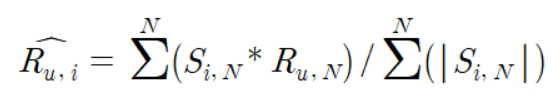
* 일단 N범위에 제약 두지 않고 모든 아이템으로 가정하고 예측 평점 구한 뒤, N 기반으로 협업 필터링 하는 로직으로 변경하자

In [9]:
###영화간의 유사도 가지는 item_sim_df와 사용자-영화 평점 ratings_matrix df --> 사용자별로 최적화된 평점 스코어를 예측하는 함수
# N 범위에 제약 두지 않는다면, Rui는 사용자 u의 모든 영화에 대한 실제 평점과 영화i의 다른 모든 영화외의 코사인 유사돌르 내적곱한 값을 정규화 위해 나눈 것
def predict_rating(ratings_arr, item_sim_arr):
    ratings_pred = ratings_arr.dot(item_sim_arr)/np.array([np.abs(item_sim_arr).sum(axis=1)])
    return ratings_pred

#개인화된 예측 평점
ratings_pred = predict_rating(ratings_matrix.values, item_sim_df.values)
ratings_pred_matrix = pd.DataFrame(data=ratings_pred, index=ratings_matrix.index, \
                                  columns=ratings_matrix.columns)
ratings_pred_matrix.head(3)

MemoryError: Unable to allocate 721. MiB for an array with shape (9719, 9719) and data type float64

* 예측 평점은 실제평점과 영화코사인유사도를 내적한 값이라, 기존에 영화 관람안해서 0이던 실제 영화 평점이 예측값에서는 값이 부여되는 경우 많음
* 예측 평점이 실제 평점에 비해 작을 수 있음 <- 내적 결가를 코사인 유사도 벡터 합으로 나누어서
* 해당 예측 결과가 원래의 실제 평점과 얼마나 차이 있나 확인해보자
  * MSE를 예측 평가 지표로 함
  * 개인화된 예측점수는 평점 유지 않은 영화에 대해서 아이템 유사도에 기반해 평점 예측했었음
  * 실제-예측 차이는 기존에 평점이 부여된 데이터 대해서만 오차 정도 측정하자

In [10]:
###MSE 계산하는 함수

from sklearn.metrics import mean_squared_error

def get_mse(pred, actual):
    #평점이 있는 실제 영화만 추출
    pred = pred[actual.nonzero()].flatten()
    actual = actual[actual.nonzero()].flatten()
    return mean_squared_error(pred, actual)

print('아이템 기반 모든 최근접 이웃의 MSE : ', get_mse(ratings_pred, ratings_matrix.values))

NameError: name 'ratings_pred' is not defined

* 실제와 예측의 스케일이 다르므로 MSE가 좀 크게 나올 수도 있음. MSE 감소시키는 방향으로 개선한다는 게 중요

In [12]:
### predict_rating() 함수를 '특정 영화와 가장 비슷한 유사도를 가지는 영화'에 대해서만  Top-n으로 유사도 벡터를 적용하도록 바꾸기
#단, 이 때는 for루프를 행렬별로 반복해야 하므로 수행 시간이 오래 걸림

def predict_rating_topsim(ratings_arr, item_sim_arr, n=20):
    #사용자-아이템 평점 행렬 크기만큼 0으로 채운 예측 행렬 초기화
    pred = np.zeros(ratings_arr.shape)
    
    #사용자-아이템 평점 행렬의 열 크기만큼 루프 수행
    for col in range(ratings_arr.shape[1]):
        #유사도 행렬에서 유사도 큰 순으로 n개 데이터 행렬의 인덱스 반환
        top_n_items = [np.argsort(item_sim_arr[:, col])[:-n-1:-1]]
        #개인화된 예측 평점을 구함
        for row in range(ratings_arr.shape[0]):
            pred[row, col] = item_sim_arr[col, :][top_n_items].dot(ratings_arr[row,:][top_n_items].T)
            pred[row, col] /= np.sum(np.abs(item_sim_arr[col, :][top_n_items]))
    return pred

###실제 평점과의 MSE구하고, 계산된 예측 평점 넘파이 행렬을 판다스 DF로 재생성
ratings_pred = predict_rating_topsim(ratings_matrix.values, item_sim_df.values, n=20)
print('아이템 기반 최근접 TOP-20 이웃 MSE : ', get_mse(ratings_pred, ratings_matrix.values))
ratings_pred_matrix = pd.DataFrame(data=ratings_pred, index=ratings_matrix.index, columns=ratings_matrix.columns)

<ipython-input-12-c72f36b071fc>:14: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  pred[row, col] = item_sim_arr[col, :][top_n_items].dot(ratings_arr[row,:][top_n_items].T)
<ipython-input-12-c72f36b071fc>:15: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  pred[row, col] /= np.sum(np.abs(item_sim_arr[col, :][top_n_items]))


아이템 기반 최근접 TOP-20 이웃 MSE :  3.695009387428144


In [13]:
###영화 추천해보기
user_rating_id = ratings_matrix.loc[9,:]
user_rating_id[user_rating_id>0].sort_values(ascending=False)[:10]

title
Adaptation (2002)                                                                 5.0
Austin Powers in Goldmember (2002)                                                5.0
Lord of the Rings: The Fellowship of the Ring, The (2001)                         5.0
Lord of the Rings: The Two Towers, The (2002)                                     5.0
Producers, The (1968)                                                             5.0
Citizen Kane (1941)                                                               5.0
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)    5.0
Back to the Future (1985)                                                         5.0
Glengarry Glen Ross (1992)                                                        4.0
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)                                     4.0
Name: 9, dtype: float64

In [15]:
###위 사용자에게 아이템 기반 협업 필터링 통해 영하ㅗ 추천하자
###이미 평점 준 영화 제외하고 추천하도록 평점 안 준 영화 리스트를 반환하는 함수 만들기
def get_unseen_movies(ratings_matrix, userId):
    #userId로 입력받은 사용자의 모든 영화 정보를 추출해 Series로 반환
    #반환된 user_rating은 영화명을 인덱스로가지는 Series 객체임
    user_rating = ratings_matrix.loc[userId, :]
    #user_rating이 0보다 크면 기존에 관람한 영화임 -> 대신 인덱스 추출해 list 객체화
    already_seen = user_rating[user_rating>0].index.tolist()
    #모든 영화명을 리스트 객체로 만듦
    movies_list = ratings_matrix.columns.tolist()
    #리스트 내포로 alreay_seen 해당하는 영하는 리스트에서 제외함
    unseen_list = [movie for movie in movies_list if movie not in already_seen]
    
    return unseen_list

In [17]:
### 사용자가 영화 평줌 주지 않은 추천 대상 영화 정보 & predict_rating_topsim()에서 추출한 사용자별 아이템 유사도 기반 예측 평점 테이터셋 이용해
### 사용자에게 영화 추천하는 함수 만들기

def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n=10):
    # 예측 평점 DF에서 사용자 아이디 인덱스와 unseen_list로 들어온 영화 칼럼명 추출 -> 가장 예측 평점 높은 순으로 정렬
    recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]
    return recomm_movies

unseen_list = get_unseen_movies(ratings_matrix, 9)
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)
recomm_movies = pd.DataFrame(data=recomm_movies.values, index=recomm_movies.index, columns=['pred_score'])
recomm_movies

,pred_score
title,
Shrek (2001),0.866202
Spider-Man (2002),0.857854
"Last Samurai, The (2003)",0.817473
Indiana Jones and the Temple of Doom (1984),0.816626
"Matrix Reloaded, The (2003)",0.800990
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001),0.765159
Gladiator (2000),0.740956
"Matrix, The (1999)",0.732693
Pirates of the Caribbean: The Curse of the Black Pearl (2003),0.689591
